# **Import required libraries**

In [20]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import requests
import calendar
import seaborn as sns
import math
from datetime import datetime 
from datetime import timedelta

# **Load and preprocess data**
This portion is to further prepare the data for initial exploratory data analysis. 
- Create a proper `'Date'` column for time-series analysis
- Calculate Monthly and Yearly average prices

From the visualization graphs, we can see an overall increasing trend in resale flat prices from $442246 in 2017 to $617867 in 2025. Particularly, we notice that the prices have:
- A plateau in 2019 to 2020
- A short period of decrease before increasing rapidly after mid-2020
    - The Straits Times reported that the **prices rose 5% in 2020** and the **transaction volume increased by 4.4%** from 2019. The writers explained that this increase, despite the economy being hit by the Covid-19 pandemic, is not surprising given the **extensive government stimulus** such as the Jobs Support Scheme to support the economy, giving buyers the condifence that they will be able to service their loan. (Source: [The Straits Times](https://www.straitstimes.com/business/property/sales-of-hdb-resale-flats-hit-8-year-high-in-2020-as-prices-climb-5))

## Resale Flat Data

In [21]:
df = pd.read_csv('../datasets/Final_ResaleData.csv')
print('Dataset shape:', df.shape)
df.sample(5)

Dataset shape: (212868, 13)


,Year,Month,Town,Flat_Type,Address,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature
171845,2024,2,BUKIT BATOK,5,354 BT BATOK ST 31,7,148.0,62.333,855000.0,494,1606,True,False
122562,2022,7,CHOA CHU KANG,3,218 CHOA CHU KANG CTRL,7,105.0,66.583,460000.0,578,471,True,False
8138,2017,6,BEDOK,4,669 JLN DAMAI,7,126.0,78.417,585000.0,376,3206,True,True
158661,2023,8,SEMBAWANG,3,314 SEMBAWANG DR,10,90.0,74.583,484000.0,973,775,True,False
1244,2017,2,BEDOK,2,536 BEDOK NTH ST 3,10,68.0,61.917,310000.0,787,1519,True,True


In [22]:
df.describe()

,Year,Month,Flat_Type,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall
count,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000,212868.000000
mean,2021.082300,6.514455,3.097051,7.584503,96.414865,74.194438,510213.368192,1077.931065,1309.502194
std,2.467264,3.361427,0.915827,5.621582,23.830564,14.202390,167007.223313,575.167499,672.138370
min,2017.000000,1.000000,0.000000,1.000000,31.000000,40.083000,140000.000000,48.000000,49.000000
25%,2019.000000,4.000000,2.000000,4.000000,77.000000,62.500000,380000.000000,660.000000,821.000000
50%,2021.000000,7.000000,3.000000,7.000000,93.000000,74.000000,485000.000000,966.000000,1197.000000
75%,2023.000000,9.000000,4.000000,10.000000,112.000000,88.500000,618000.000000,1376.000000,1689.000000
max,2025.000000,12.000000,6.000000,49.000000,215.000000,97.750000,985000.000000,6250.000000,5374.000000


In [11]:
# Add 'Date' column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values('Date')

# Add additional time-related columns
df['Quarter'] = df['Date'].dt.to_period('Q')

print(df.head(5))
print(f"Data spans from {df['Date'].min()} to {df['Date'].max()}")
print(f"Total number of transactions: {len(df)}")
print(f"\nTransactions per year:")
print(df.groupby('Year').size())

     Year  Month        Town  Flat_Type                Address  Storey  \
0    2017      1  ANG MO KIO          1  406 ANG MO KIO AVE 10      10   
792  2017      1   SEMBAWANG          3       322 SEMBAWANG CL       4   
791  2017      1   SEMBAWANG          3       477 SEMBAWANG DR       1   
790  2017      1  QUEENSTOWN          4      52 STRATHMORE AVE      19   
789  2017      1  QUEENSTOWN          4          18 DOVER CRES      19   

     Floor_Area  Remaining_Lease     Price  Distance_MRT  Distance_Mall  \
0          44.0           61.333  232000.0          1148           1276   
792       100.0           81.333  335000.0           558            385   
791        86.0           82.500  305000.0           851            830   
790       110.0           88.917  860000.0           293            737   
789       111.0           85.667  800000.0           757            951   

     Within_1km_of_Pri  Mature       Date Quarter  
0                 True    True 2017-01-01  2017Q1  


In [15]:
# Calculate Monthly Average Prices
monthlyAvgPrices = df.groupby('Date').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

monthlyAvgPrices.columns = ['Date', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
monthlyAvgPrices.sample(5)

# Calculate Yearly Average Prices
yearlyAvgPrices = df.groupby('Year').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()  
 
yearlyAvgPrices.columns = ['Year', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
yearlyAvgPrices.sample(5)

print('Monthly Average Prices (first 5 rows):' )
print(monthlyAvgPrices.head(5))
print('\nYearly Average Prices:')
print(yearlyAvgPrices)


Monthly Average Prices (first 5 rows):
        Date     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0 2017-01-01  426443.598478      403000.0  130267.530484               1183
1 2017-02-01  446722.903137      415000.0  146588.271232               1084
2 2017-03-01  443729.275345      415000.0  144431.360286               1899
3 2017-04-01  437682.043377      408000.0  139008.292703               1836
4 2017-05-01  442003.979737      410000.0  145710.924400               1974

Yearly Average Prices:
   Year     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0  2017  442246.549403      410000.0  146053.062002              20452
1  2018  438775.588278      408000.0  152961.360201              21472
2  2019  430058.837131      400000.0  149934.544788              22112
3  2020  449820.332213      425000.0  149765.177374              23240
4  2021  505604.462313      480000.0  152752.358872              28794
5  2022  540876.684146      520000.0  156143.259282    

### Visualization of overall price trend

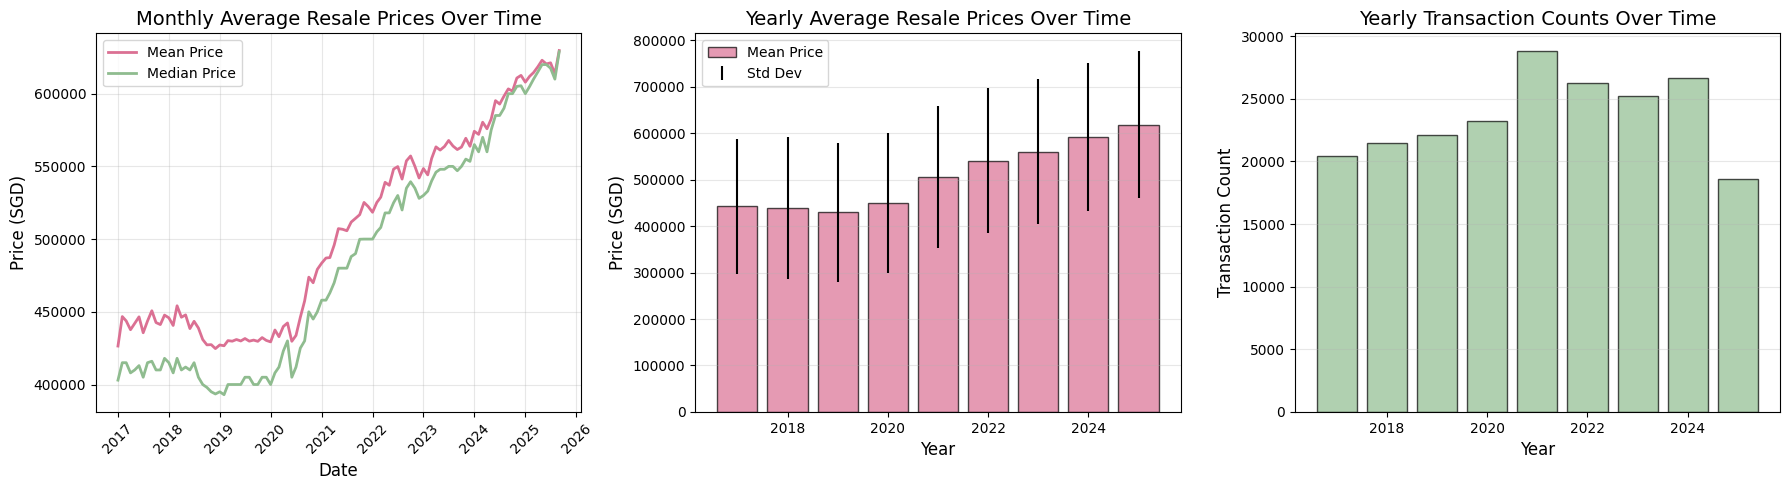

In [24]:
fig, ax =  plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Monthly Average Resale Prices Over Time
ax[0].plot(monthlyAvgPrices['Date'], monthlyAvgPrices['Mean_Price'],
           linewidth=2, label='Mean Price', color='palevioletred')
ax[0].plot(monthlyAvgPrices['Date'], monthlyAvgPrices['Median_Price'],
           linewidth=2, label='Median Price', color='darkseagreen')
ax[0].set_title('Monthly Average Resale Prices Over Time', fontsize=14)
ax[0].set_xlabel('Date', fontsize=12)
ax[0].set_ylabel('Price (SGD)', fontsize=12)
ax[0].legend(loc = 'upper left')
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='x', rotation=45)

# Plot 2: Yearly Average Resale Prices Over Time
ax[1].bar(yearlyAvgPrices['Year'], yearlyAvgPrices['Mean_Price'],
          color='palevioletred', alpha=0.7, label='Mean Price', edgecolor='black')
ax[1].errorbar(yearlyAvgPrices['Year'], yearlyAvgPrices['Mean_Price'],
               yerr=yearlyAvgPrices['Std_Dev_Price'], fmt='none', color='black', label='Std Dev')
ax[1].set_title('Yearly Average Resale Prices Over Time', fontsize=14)
ax[1].set_xlabel('Year', fontsize=12)
ax[1].set_ylabel('Price (SGD)', fontsize=12)
ax[1].legend(loc = 'upper left')
ax[1].grid(True, alpha=0.3, axis = 'y')

# Plot 3: Yearly Transaction Counts Over Time
ax[2].bar(yearlyAvgPrices['Year'], yearlyAvgPrices['Transaction_Count'],
          color='darkseagreen', alpha=0.7, label='Transaction Count', edgecolor='black')
ax[2].set_title('Yearly Transaction Counts Over Time', fontsize=14)
ax[2].set_xlabel('Year', fontsize=12)
ax[2].set_ylabel('Transaction Count', fontsize=12)
ax[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## HDB Features Data

In [14]:
features = pd.read_csv('../datasets/HDB_Features.csv')
print('Dataset shape:', features.shape)
features.sample(5)

Dataset shape: (9659, 9)


,Address,Lat,Long,Nearest_MRT,Distance_MRT,Nearest_Mall,Distance_Mall,Nearest_Pri_Sch,Within_1km_of_Pri
816,420 SERANGOON CTRL,1.349149,103.875117,Serangoon MRT,378,NEX,463,Yangzheng Primary School,True
7248,451 SIN MING AVE,1.358511,103.830067,Upper Thomson MRT,834,Thomson Plaza,1028,Ai Tong School,True
7728,99C LOR 2 TOA PAYOH,1.339016,103.847449,Braddell MRT,340,Junction 8,2464,Kheng Cheng School,True
5542,286 TAMPINES ST 22,1.349537,103.952988,Simei MRT,1226,Eastpoint Mall,1265,Chongzheng Primary School,True
6491,532 PASIR RIS DR 1,1.371277,103.950747,Pasir Ris MRT,583,Downtown East,1491,Elias Park Primary School,True
